In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torchvision.datasets as datasets
from scipy import stats

# Create a FNN able to sum two numbers

In [9]:
def create_synthetic_data(num_samples=1000, num_features=2, range=(-10, 10), integer=False):
    if integer:
        X = np.random.randint(range[0], range[1], size=(num_samples, num_features))
        y = np.sum(X, axis=1)
    else:
        X = np.random.uniform(range[0], range[1], size=(num_samples, num_features))
        y = np.sum(X, axis=1)

    X = torch.tensor(X, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    # we dont normalize the data, we want to see how the model performs with large values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    train_dataset = TensorDataset(X_train, y_train)
    test_dataset = TensorDataset(X_test, y_test)

    batch_size = 32
    train_dl = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    test_dl = DataLoader(test_dataset, batch_size=test_dataset.tensors[0].shape[0], shuffle=False)

    return train_dl, test_dl

class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x
    
def train_one_epoch(model, train_dl, optimizer, loss_fn):
    model.train()
    epoch_loss = []

    for X_batch, y_batch in train_dl:
        output = model(X_batch)
        loss = loss_fn(output, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss.append(loss.item())
        
    return np.mean(epoch_loss)

def train_model(model, train_dl, test_dl, optimizer, loss_fn, epochs):
    
    train_loss = np.zeros(epochs)
    test_loss = np.zeros(epochs)
    
    for epoch in range(epochs):
        train_loss[epoch] = train_one_epoch(model, train_dl, optimizer, loss_fn)
        
        model.eval()
        with torch.no_grad():
            for X_batch, y_batch in test_dl:
                output = model(X_batch)
                test_loss[epoch] = loss_fn(output, y_batch).item() 

    return train_loss, test_loss

In [10]:
learning_rate = 0.0001
epochs = 100

# loss for regression problems is usually MSELoss, but we can also use L1Loss or HuberLoss
loss_fn = nn.MSELoss()
train_dl, test_dl = create_synthetic_data(num_samples=5000, num_features=2, range=(-1000, 1000), integer=True)

model = SimpleNN(input_size=2, hidden_size=10, output_size=1)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-3)
train_loss, test_loss = train_model(model, train_dl, test_dl, optimizer, loss_fn, epochs)

In [21]:
output = model(train_dl.dataset.tensors[0][:5])
print(torch.sum(train_dl.dataset.tensors[0][:5], dim=1))
print(torch.round(output))

tensor([-432., -521.,  351.,  922., -127.])
tensor([[-425.],
        [-520.],
        [ 350.],
        [ 920.],
        [-130.]], grad_fn=<RoundBackward0>)


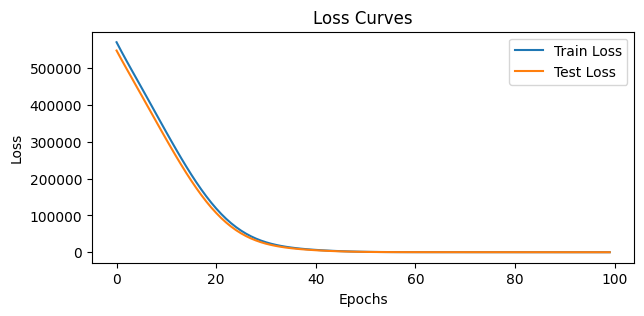

In [11]:
fig = plt.figure(figsize=(7, 3))
plt.plot(train_loss, label='Train Loss')
plt.plot(test_loss, label='Test Loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

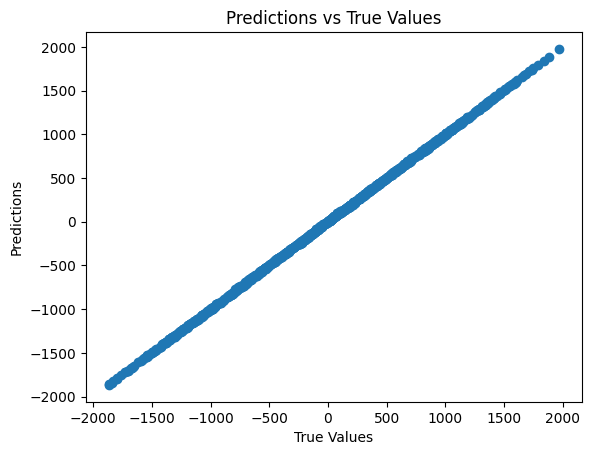

In [22]:
# plot the predictions vs the true values
model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_dl:
        output = model(X_batch)
        plt.scatter(y_batch.numpy(), output.numpy())
        plt.xlabel('True Values')
        plt.ylabel('Predictions')
        plt.title('Predictions vs True Values')
        plt.show()

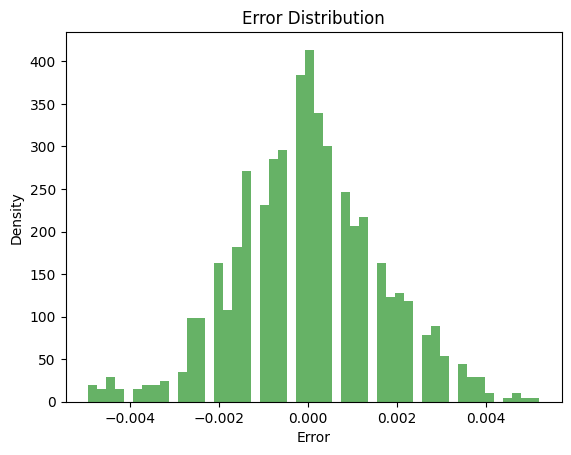

In [ ]:
# plot the error distribution normalized to the range of the data
model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_dl:
        output = model(X_batch)
        error = (y_batch - output).numpy().flatten()
        error = error / (y_batch.max().item() - y_batch.min().item())  # normalize to the range of the data
        plt.hist(error, bins=50, density=True, alpha=0.6, color='g')
        plt.title('Error Distribution')
        plt.xlabel('Error')
        plt.ylabel('Density')
        plt.show()